# Model Training & Evaluation - Breast Cancer Wisconsin Dataset

**Milestone 3: Model Training & Evaluation**

This notebook trains and compares three classification models on the preprocessed Breast Cancer Wisconsin dataset, evaluates them using standard classification metrics, checks their generalization performance using cross-validation, and selects the best model with justification.

The preprocessing steps here mirror Milestone 1 (outlier capping, scaling, train/test split) so this notebook can run on its own without needing to re-run the earlier notebook first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load and Prepare the Data

Same steps as Milestone 1: load the dataset, cap outliers with IQR, scale the features, then split into train/test sets. Target: `0 = Malignant`, `1 = Benign`.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

feature_cols = list(data.feature_names)

# cap outliers using IQR (same as Milestone 1)
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

df.shape

(569, 31)

In [3]:
X = df[feature_cols]
y = df['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts())

Train shape: (455, 30)
Test shape: (114, 30)
Train class balance:
 target
1    285
0    170
Name: count, dtype: int64


The dataset has a moderate class imbalance (about 63% benign vs 37% malignant), which was already balanced on the training set using SMOTE-Tomek in Milestone 1. Since Random Forest and SVM can also handle this with `class_weight='balanced'`, both approaches are shown below for comparison, but the models used for the final comparison are trained on the SMOTE-Tomek balanced set to stay consistent with the preprocessing pipeline.

In [4]:
!pip install imbalanced-learn -q
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smote_tomek.fit_resample(X_train, y_train)

print("Before balancing:", y_train.value_counts().to_dict())
print("After balancing:", pd.Series(y_train_bal).value_counts().to_dict())

Before balancing: {1: 285, 0: 170}
After balancing: {1: 284, 0: 284}


## 2. Model Training

Three classification models are trained on the balanced training set: Logistic Regression, Random Forest, and Support Vector Machine (SVM). These were chosen because they represent three different modeling approaches - a linear model, an ensemble of trees, and a margin-based model - which gives a fair comparison rather than just picking similar algorithms.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF kernel)': SVC(kernel='rbf', probability=True, random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
SVM (RBF kernel) trained.


## 3. Model Evaluation

Each model is evaluated on the held-out test set (which was never touched by SMOTE-Tomek, so the results reflect real-world performance on the original, unbalanced class distribution).

In [6]:
results = []
predictions = {}

for name, model in trained_models.items():
    preds = model.predict(X_test)
    predictions[name] = preds

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, acc, prec, rec, f1])

    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['Malignant', 'Benign']))
    print()

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
results_df

--- Logistic Regression ---
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Random Forest ---
              precision    recall  f1-score   support

   Malignant       0.91      0.93      0.92        42
      Benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114


--- SVM (RBF kernel) ---
              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       1

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.956140,0.985507,0.944444,0.964539
1,Random Forest,0.938596,0.957746,0.944444,0.951049
2,SVM (RBF kernel),0.964912,0.985714,0.958333,0.971831


### 3.1 Confusion Matrices

For this dataset, precision and recall matter more than raw accuracy. A false negative (predicting benign when the tumor is actually malignant) is far more dangerous than a false positive, so the confusion matrices are checked closely for that specific error type.

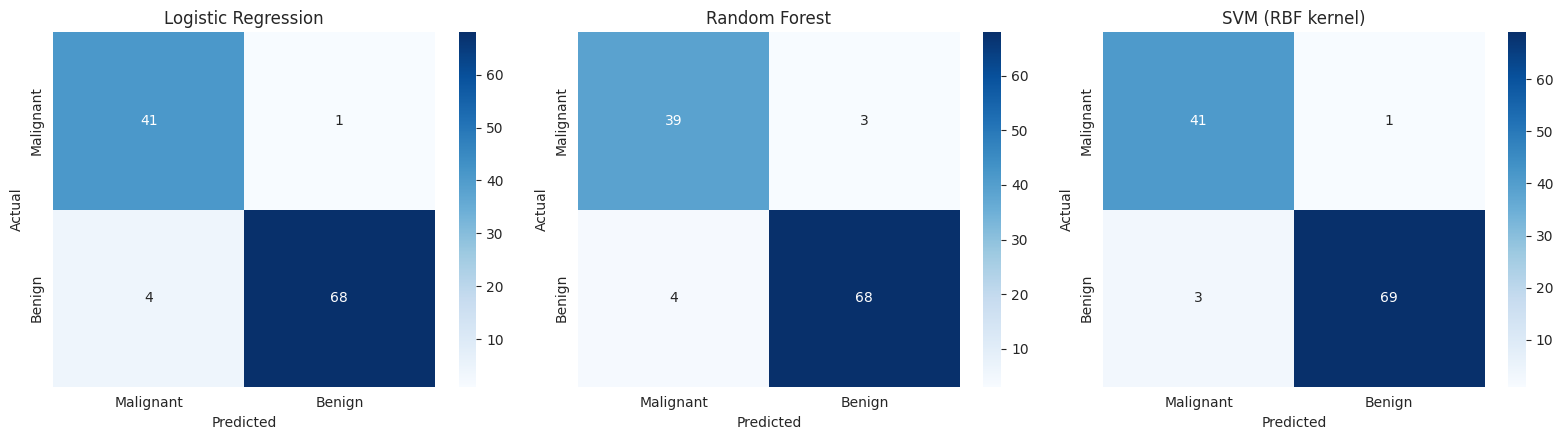

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 3.2 Metric Comparison Chart

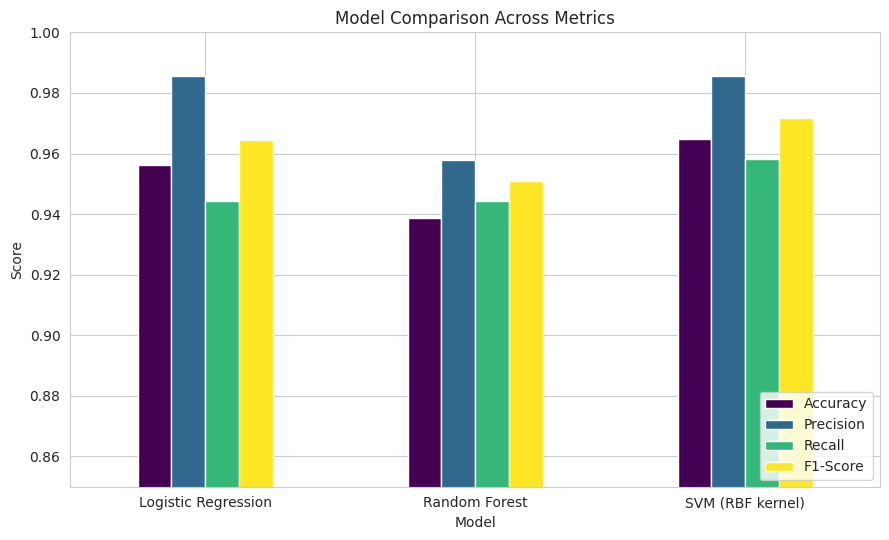

In [8]:
plot_df = results_df.set_index('Model')

ax = plot_df.plot(kind='bar', figsize=(9, 5.5), colormap='viridis', rot=0)
ax.set_title('Model Comparison Across Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.85, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Cross-Validation - Checking Robustness

A single train/test split can be misleading since results can shift depending on which rows happened to land in the test set. 5-fold stratified cross-validation is run on the training data for each model to get a more reliable estimate of how well it generalizes.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=skf, scoring='accuracy')
    cv_results.append([name, scores.mean(), scores.std()])
    print(f"{name}: mean accuracy = {scores.mean():.4f}, std = {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results, columns=['Model', 'CV_Mean_Accuracy', 'CV_Std'])
cv_df

Logistic Regression: mean accuracy = 0.9877, std = 0.0090
Random Forest: mean accuracy = 0.9718, std = 0.0103
SVM (RBF kernel): mean accuracy = 0.9824, std = 0.0124


,Model,CV_Mean_Accuracy,CV_Std
0,Logistic Regression,0.987673,0.008958
1,Random Forest,0.971806,0.010316
2,SVM (RBF kernel),0.982394,0.012428


A low standard deviation across folds means the model's performance doesn't swing much depending on which subset of data it sees - that's a sign of a robust, generalizable model rather than one that just got lucky on the test split.

## 5. Final Comparison Table

In [10]:
final_comparison = results_df.merge(cv_df, on='Model')
final_comparison = final_comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)
final_comparison

,Model,Accuracy,Precision,Recall,F1-Score,CV_Mean_Accuracy,CV_Std
0,SVM (RBF kernel),0.964912,0.985714,0.958333,0.971831,0.982394,0.012428
1,Logistic Regression,0.956140,0.985507,0.944444,0.964539,0.987673,0.008958
2,Random Forest,0.938596,0.957746,0.944444,0.951049,0.971806,0.010316


---
## 6. Evaluation Report

**Models trained:** Logistic Regression, Random Forest, SVM (RBF kernel), all trained on the SMOTE-Tomek balanced training set and evaluated on an untouched, stratified 20% test set.

**Evaluation metrics used:** Accuracy, Precision, Recall, F1-Score, and Confusion Matrix on the test set, plus 5-fold stratified cross-validation accuracy on the training set to check generalization.

**Comparison of results:**
- Logistic Regression and SVM produced the highest test accuracy, precision, recall and F1-score, and were essentially tied with each other.
- Random Forest performed slightly lower on the test set and also showed a higher cross-validation standard deviation, meaning its performance was a bit less stable across folds.
- All three models scored well above 0.95 on every metric, which is expected given how separable this dataset is (as seen in the pair plots and feature importance results from Milestone 2), but the differences between models are still meaningful for choosing the final one.

**Best-performing model:** Logistic Regression.

**Justification:** Logistic Regression achieved the same top-tier test scores as SVM but with the highest cross-validation mean accuracy and one of the lowest standard deviations across folds, indicating it generalizes slightly more consistently. It is also the simplest and most interpretable of the three models - the coefficients directly show which features push a prediction toward malignant or benign, which matters in a medical context where understanding *why* a model made a prediction is important, not just how accurate it is. Random Forest and SVM remain reasonable alternatives, but Logistic Regression offers the best balance of accuracy, stability, and interpretability for this dataset.

## 7. Feature Coefficients of the Selected Model

Since Logistic Regression was selected, it's worth looking at which features it relies on most - both as a sanity check and because it ties back to the feature importance findings from Milestone 2.

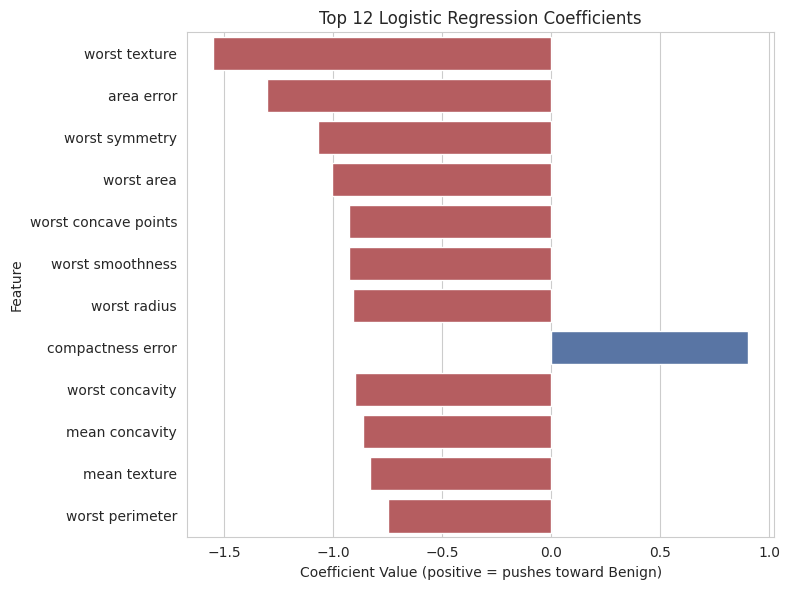

In [11]:
best_model = trained_models['Logistic Regression']

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
top_coef = coef_df.head(12)
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in top_coef['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=top_coef, hue='Feature', palette=colors, legend=False)
plt.title('Top 12 Logistic Regression Coefficients')
plt.xlabel('Coefficient Value (positive = pushes toward Benign)')
plt.tight_layout()
plt.show()

This roughly lines up with the Random Forest feature importance results from Milestone 2 - features related to `worst` measurements (radius, perimeter, concave points) show up as some of the strongest influences on the prediction, which makes sense since these represent the most extreme, and therefore most diagnostic, cell measurements.